# Application of MJO RMM components 


```{image} ../thumbnails/thumbnail.png
:alt: Project Pythia logo
:width: 200px
```

In [6]:
#reference for the location plot 
#Donald, Alexis & Meinke, Holger & Power, Brendan & Wheeler, Matthew & Ribbe, Joachim. (2004). Forecasting with the Madden-Julian Oscillation and the applications for risk management. 

## Overview

The **Madden–Julian Oscillation (MJO)** is an eastward-propagating tropical disturbance characterized by large-scale anomalies in atmospheric circulation and deep convection.

Its state is commonly described using the **Real-time Multivariate MJO (RMM) index**, which is derived from the leading two multivariate empirical orthogonal functions (EOFs) of equatorially averaged outgoing longwave radiation (OLR) and zonal winds at 200 hPa and 850 hPa, following Wheeler and Hendon RMM Index ([Wheeler and Hendon, 2004](https://doi.org/10.1175/1520-0493(2004)132,1917:AARMMI.2.0.CO;2.)). 

The RMM index defines eight phases (1–8) that represent the canonical eastward progression of MJO-related convection and circulation anomalies around the tropics. Phases 1–4 correspond primarily to enhanced convection over the Indian Ocean, while phases 5–8 indicate active MJO conditions over the western Pacific ([Kiladis et al., 2014](https://doi.org/10.1175/MWR-D-13-00301.1.)).

So in this tutorial, we will learn the application of EOF analysis we learned **link the repo** in context of the MJO.

```{image} figures/omi-phase-daigram-example.png
:alt: sample phase daigram
:width: 200px
```

```{image} figures/Approximate-locations-of-the-MJO.jpg
:alt: location of MJO
:width: 200px
```

## Prerequisites

### Data Access

1. RMM index data were obtained from the Australian Bureau of Meteorology: [Link](http://www.bom.gov.au/climate/mjo/graphics/rmm.74toRealtime.txt).
   
Or if you want to compute these indices with your data:
1. Follow the tutuorial our earlier tutorial on the RMM index calculation (**Link the repo**)
1. global 3-D field (OLR, U850, U200, geopotential height,..) can be downloaded using the [notebook](spectral-analysis-cookbook/notebooks/SpectralAnalysisDataSetAccess.ipynb)


## Workflow

1. Once we have our RMM1 (PC1) and RMM2 (PC2) components; a common practice to visualize the MJO propagation is the the MJO phase daigram. So our first step will be,
   - plotting MJO phase diagrams
1. Regression onto the Principal Components
    - Regress each global 3-D field (OLR, U850, U200, geopotential height,...) on RMM1 and RMM2.
        - Before regressing, we have to preprocessing the data to isolate the MJO signal. Common practices include(do not need),
            -  remove the seasonal cycle (by removing the first three harmonics). - **add link**
            -  remove the ENSO signal (Regressiong out the first two EOF components of the Sea Surface Temperature)
            -  Substracting a 120 days running mean.
        - Once we have isolated the MJO signals; we can regress our RMM components on to different fields like OLR, winds and etc.  
    - Reconstruct the MJO life cycle by taking linear combinations of the two regression maps: -PC2, (PC1 - PC2)/sqrt(2), PC1, (PC1 + PC2)/sqrt(2), PC2.
    - Compare the reconstructed maps with Wheeler and Hendon (2004) and Adames and Wallace (2014).

## Imports

In [7]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import s3fs
import xarray as xr


In [8]:
# hide-cell
# function to download MJO indices
def load_mjo(url, kind="rmm"):
    """
    Unified loader for MJO indices: RMM or OMI.

    Returns standardized dataframe:
    index = datetime
    columns = pc1, pc2, phase, amplitude
    """

    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers)
    r.raise_for_status()
    data = StringIO(r.text)

    if kind.lower() == "rmm":

        df = pd.read_csv(
            data,
            sep=r"\s+",
            header=None,
            skiprows=2,
            engine="python"
        )

        df = df.iloc[:, :7]
        df.columns = ["year", "month", "day", "pc1", "pc2", "phase", "amplitude"]

    elif kind.lower() == "omi":

        df = pd.read_csv(
            data,
            sep=r"\s+",
            header=None,
            comment="#",
            engine="python"
        )

        df = df.iloc[:, :7]
        df.columns = ["year", "month", "day", "hour", "pc1", "pc2", "amplitude"]

    else:
        raise ValueError("kind must be 'rmm' or 'omi'")

    # datetime index
    df["date"] = pd.to_datetime(df[["year", "month", "day"]])
    df = df.set_index("date")

    # --- OMI: compute phase if needed ---
    if kind.lower() == "omi":
        angle = np.arctan2(df["pc2"].values, df["pc1"].values)
        df["phase"] = ((np.degrees(angle) + 360) % 360 // 45 + 1).astype(int)

    # select standard output
    return df[["pc1", "pc2", "phase", "amplitude"]]


## Getting starting

Lets read the data get started

In [9]:
url_rmm = "https://www.bom.gov.au/climate/mjo/graphics/rmm.74toRealtime.txt"

rmm = load_mjo(url_rmm, kind="rmm")

#rmm.head()
#omi.head()

# now print the time period
print("\nRMM available period:")
print(rmm.index.min(), "to", rmm.index.max())

#slice the data for desired time
common_start = '1980-06-01'
common_end = '2024-02-24'
rmm = rmm.loc[common_start:common_end]

# now print again
print("\nRMM period:")
print(rmm.index.min(), "to", rmm.index.max())


RMM available period:
1974-06-01 00:00:00 to 2024-02-24 00:00:00

RMM period:
1980-06-01 00:00:00 to 2024-02-24 00:00:00



## Comparison of RMM PCs
Now lets plot the components first; then lets do a phase daigram for an event;

Text(0.5, 1.0, 'Comparison of RMM1 and RMM2')

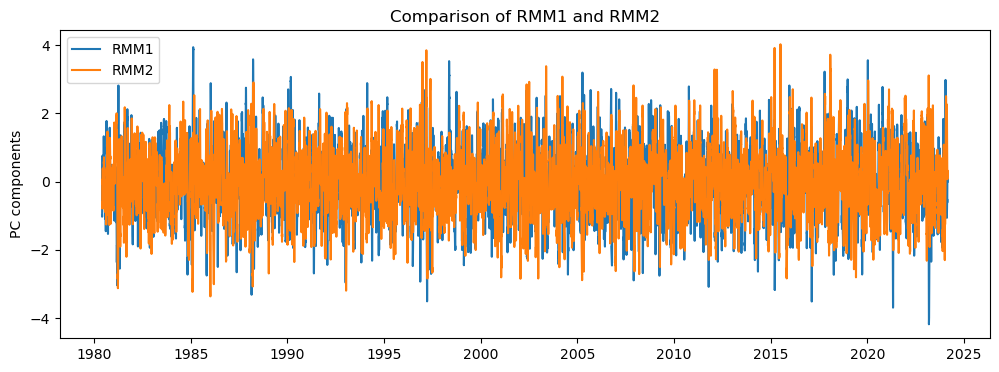

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(rmm.index,
        rmm["pc1"],
        label="RMM1")

ax.plot(rmm.index,
        rmm["pc2"],
        label="RMM2")

ax.legend()

ax.set_ylabel("PC components")
ax.set_title("Comparison of RMM1 and RMM2")
    

Ploting the same but with a smoothing (running mean) to see the differences. Lets do a 6 days running mean. 

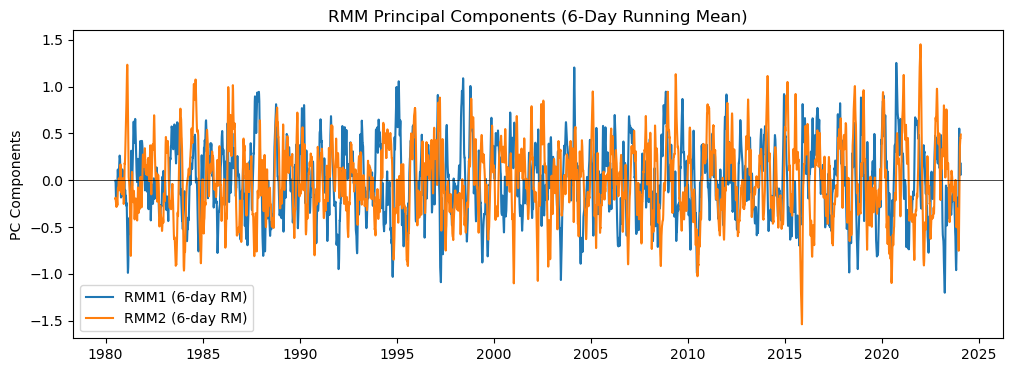

In [11]:

import matplotlib.pyplot as plt

# 6-day running mean
rmm_smooth = rmm.rolling(window=60, center=True).mean()

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(
    rmm_smooth.index,
    rmm_smooth["pc1"],
    label="RMM1 (6-day RM)"
)

ax.plot(
    rmm_smooth.index,
    rmm_smooth["pc2"],
    label="RMM2 (6-day RM)"
)
ax.axhline(0, color="k", linewidth=0.5)

ax.legend()
ax.set_ylabel("PC Components")
ax.set_title("RMM Principal Components (6-Day Running Mean)")

plt.show()

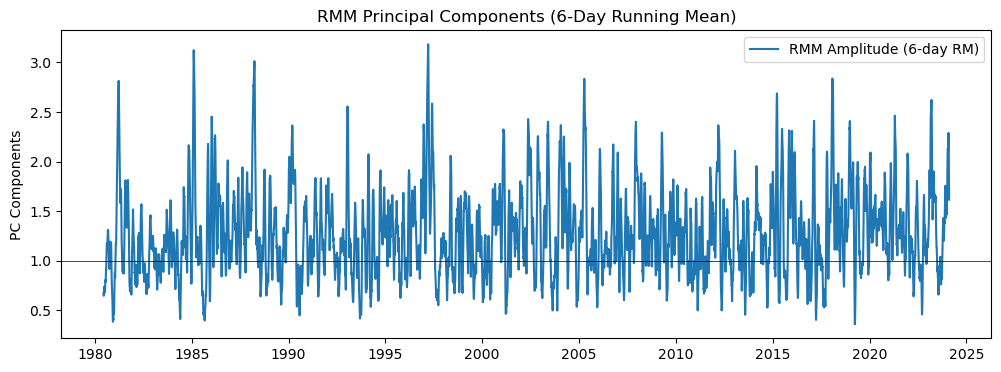

In [12]:

import matplotlib.pyplot as plt

# 6-day running mean
rmm_smooth = rmm.rolling(window=30, center=True).mean()

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(
    rmm_smooth.index,
    rmm_smooth["amplitude"],
    label="RMM Amplitude (6-day RM)"
)
ax.axhline(1, color="k", linewidth=0.5)

ax.legend()
ax.set_ylabel("PC Components")
ax.set_title("RMM Principal Components (6-Day Running Mean)")

plt.show()

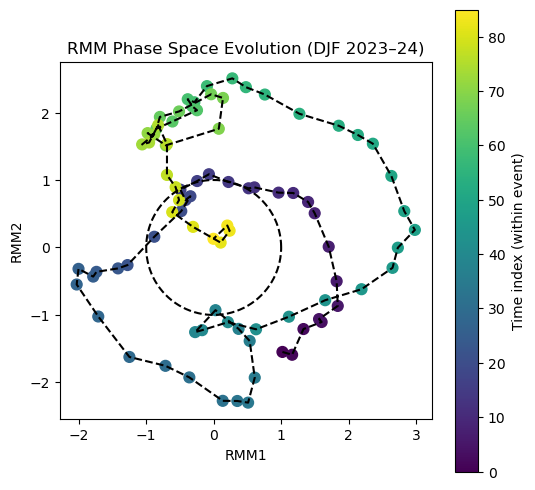

In [13]:
start = "2023-12-01"
end   = "2024-02-24"

rmm_event = rmm.loc[start:end]


fig, ax = plt.subplots(figsize=(6,6))

t = np.arange(len(rmm_event))

ax.plot(rmm_event["pc1"], rmm_event["pc2"],'k--')

sc = ax.scatter(
    rmm_event["pc1"],
    rmm_event["pc2"],
    c=t,
    cmap="viridis",
    s=60
)


theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--')

ax.set_aspect("equal")
ax.set_title("RMM Phase Space Evolution (DJF 2023–24)")
ax.set_xlabel("RMM1")
ax.set_ylabel("RMM2")

plt.colorbar(sc, label="Time index (within event)")
plt.show()


## Preprocessing different fields to isolate the MJO signal. 

As mentioned earlier, the common practices include(do not need all of these),
- remove the seasonal cycle (by removing the first three harmonics). - add link
- remove the ENSO signal (Regressiong out the first two EOF components of the Sea Surface Temperature)- we wont be doing this, but follow our EOF tutorial **add link** if you are required to do so.
- Substracting a 120 days running mean.

### Step 1: fetching the data

In [15]:
URL = 'https://js2.jetstream-cloud.org:8001/' #Locate and read a file
fs = s3fs.S3FileSystem(anon=True, client_kwargs=dict(endpoint_url=URL))

olr_noaa_store = s3fs.S3Map(
    root=f'pythia/olr_noaa.zarr',
    s3=fs,
    check=False
)

# Open with xarray
olr_noaa = xr.open_zarr(olr_noaa_store)
olr_noaa


<xarray.Dataset> Size: 242MB
Dimensions:                        (time: 16802, lat: 25, lon: 144)
Coordinates:
  * lat                            (lat) float32 100B 30.0 27.5 ... -27.5 -30.0
  * lon                            (lon) float32 576B 0.0 2.5 ... 355.0 357.5
  * time                           (time) datetime64[ns] 134kB 1979-01-01T12:...
Data variables:
    __xarray_dataarray_variable__  (time, lat, lon) float32 242MB dask.array<chunksize=(1024, 25, 144), meta=np.ndarray>

Some extra steps to make sure the data has no NaN values, if so interpolate it.

In [18]:
# Make sure time is sorted
olr_noaa = olr_noaa.sortby("time")

# Check variable names
print(olr_noaa.data_vars)

# Optional: check which days have all missing OLR data
da = olr_noaa["__xarray_dataarray_variable__"]


Data variables:
    __xarray_dataarray_variable__  (time, lat, lon) float32 242MB dask.array<chunksize=(1024, 25, 144), meta=np.ndarray>


Days with all missing data:
['1980-06-04T12:00:00.000000000' '1981-03-24T12:00:00.000000000'
 '1981-03-25T12:00:00.000000000' '1981-03-26T12:00:00.000000000'
 '1981-03-27T12:00:00.000000000' '1981-03-28T12:00:00.000000000'
 '1981-03-29T12:00:00.000000000' '1981-03-30T12:00:00.000000000'
 '1981-03-31T12:00:00.000000000' '1981-04-01T12:00:00.000000000'
 '1981-04-02T12:00:00.000000000' '1981-04-03T12:00:00.000000000'
 '1981-04-04T12:00:00.000000000' '1981-04-05T12:00:00.000000000'
 '1981-04-06T12:00:00.000000000' '1981-04-07T12:00:00.000000000'
 '1981-04-08T12:00:00.000000000' '1982-09-22T12:00:00.000000000'
 '1982-09-23T12:00:00.000000000' '1983-08-03T12:00:00.000000000'
 '1984-01-11T12:00:00.000000000' '1984-01-12T12:00:00.000000000'
 '1984-12-03T12:00:00.000000000' '1985-09-22T12:00:00.000000000'
 '1985-09-23T12:00:00.000000000' '1986-03-12T12:00:00.000000000']


Text(0.5, 1.0, 'Interpolated OLR on 1980-06-04T12:00:00')

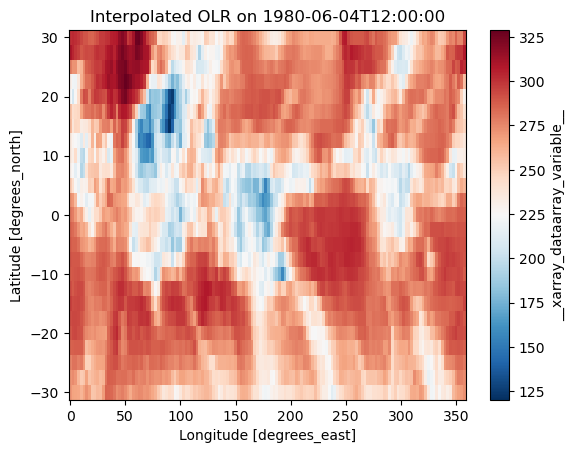

In [19]:

spatial_dims = [d for d in da.dims if d != "time"]

bad_days = da.isnull().all(dim=spatial_dims).compute()
print("Days with all missing data:")
print(da.time.where(bad_days, drop=True).values)

# Rechunk so time is one chunk
olr_noaa_chunked = olr_noaa.chunk({"time": -1})

# Linear interpolation along time
olr_noaa_filled = olr_noaa_chunked.interpolate_na(
    dim="time",
    method="linear"
)

# Plot one day (with only NaN data)
missing_day = np.datetime64("1980-06-04T12:00:00")

olr_noaa_filled["__xarray_dataarray_variable__"].sel(time=missing_day).plot(
    x="lon",
    y="lat",
    cmap="RdBu_r"
)

plt.title(f"Interpolated OLR on {missing_day}")

In [27]:
#olr_noaa_filled.to_array("olr")
olr_noaa_da = olr_noaa_filled["__xarray_dataarray_variable__"]
olr_noaa_da

<xarray.DataArray '__xarray_dataarray_variable__' (time: 16802, lat: 25,
                                                   lon: 144)> Size: 242MB
dask.array<transpose, shape=(16802, 25, 144), dtype=float32, chunksize=(16802, 25, 144), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 134kB 1979-01-01T12:00:00 ... 2024-12-31T1...
Attributes:
    regrid_method:  conservative

### Step 2: Removing the seasoanal cycle
we will be removing the first three harmonics following the tutorial **add link**. This follows the standard MJO preprocessing approach of removing the annual cycle plus a few higher-order harmonics before performing regression or EOF analysis.


In [22]:

def remove_seasonal_cycle_harmonic(data, n_harmonics=4, year_period=365.25):
    """
    Remove seasonal cycle using harmonic regression.

    Parameters
    ----------
    data : ndarray
        3D array with shape (time, lat, lon). No NaN values.
    n_harmonics : int
        Number of harmonic pairs (sin/cos) to fit.
    year_period : float
        Period of the seasonal cycle in time units.

    Returns
    -------
    anomalies : ndarray
        Data with seasonal cycle removed, same shape as input.
    """

    n_time, n_lat, n_lon = data.shape
    data_2d = data.reshape(n_time, -1)

    # Build design matrix
    t = np.arange(n_time)
    X = np.ones((n_time, 2 * n_harmonics + 1))

    for i in range(1, n_harmonics + 1):
        X[:, 2*i - 1] = np.sin(i * 2 * np.pi * t / year_period)
        X[:, 2*i] = np.cos(i * 2 * np.pi * t / year_period)

    # Least-squares fit
    coeffs = np.linalg.lstsq(X, data_2d, rcond=None)[0]

    # Remove seasonal cycle
    anomalies = data_2d - X @ coeffs

    return anomalies.reshape(n_time, n_lat, n_lon)

In [34]:
olr_ano = remove_seasonal_cycle_harmonic(olr_noaa_da.values, n_harmonics=4, year_period=365.25)

Now lets substract a 120 days running mean

In [44]:
type(olr_ano)
olr_ano_xr = xr.DataArray(
    olr_ano,
    coords=olr_noaa.coords,
    dims=olr_noaa.dims,
    name="olr_anom"

In [51]:
# 6-day running mean
rmm_smooth_120 = olr_ano_xr.rolling(time=120, center=True).mean()
# substract the running mean

olr_mjo = olr_ano_xr - rmm_smooth_120

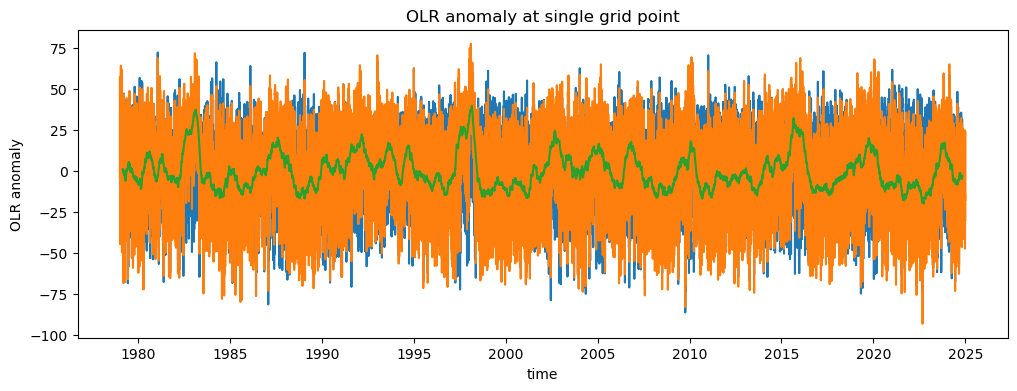

In [54]:

point = olr_ano_xr.sel(lat=0.0, lon=120.0, method="nearest")
point2 = rmm_smooth_120.sel(lat=0.0, lon=120.0, method="nearest")
point1 = olr_mjo.sel(lat=0.0, lon=120.0, method="nearest")


plt.figure(figsize=(12,4))


point1.plot()
point.plot()
point2.plot()

plt.title("OLR anomaly at single grid point")
plt.ylabel("OLR anomaly")
plt.show()

##  Regressing PC components onto the fields.

Once we have done isolating the MJO signals; we can regress our RMM components on to different fields like OLR, winds and etc.


For a two-dimensional matrix  that represents a variable field S, the equation for linear regression takes the form,



OLR′(x,y,t)=a(x,y)RMM1(t)+b(x,y)RMM2(t)


We compute regression coefficients using covariance:

a=
var(PC)
cov(OLR,PC)
	​


as well as $m = a * t / h$ text! Similarly, you have access to other $\LaTeX$ equation [**functionality**](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Typesetting%20Equations.html) via MathJax:

\begin{align}
\dot{x} & = \sigma(y-x) \\
\dot{y} & = \rho x - y - xz \\
\dot{z} & = -\beta z + xy
\end{align}

In [ ]:
#olr = olr_noaa.rename({"__xarray_dataarray_variable__": "olr"})
#olr = olr["olr"]

rmm = rmm.sel(
    index=slice(olr.time.min().values, olr.time.max().values)
)

rmm = rmm.rename_axis("time")

olr, rmm = xr.align(olr, rmm, join="inner")

pc1 = rmm["pc1"]
pc2 = rmm["pc2"]



In [ ]:
rmm1_reg = (
    (olr_anom * pc1).mean("time")
    / (pc1 ** 2).mean("time")
)

In [ ]:
rmm2_reg = (
    (olr_anom * pc2).mean("time")
    / (pc2 ** 2).mean("time")
)

In [ ]:
rmm1_reg.plot(cmap="RdBu_r")
plt.title("OLR Regression onto RMM1")
plt.show()

In [ ]:
rmm2_reg.plot(cmap="RdBu_r")
plt.title("OLR Regression onto RMM2")
plt.show()

Check out [**any number of helpful Markdown resources**](https://www.markdownguide.org/basic-syntax/) for further customizing your notebooks and the [**MyST Syntax Overview**](https://mystmd.org/guide/syntax-overview) for MyST-specific formatting information. Don't hesitate to ask questions if you have problems getting it to look *just right*.

We also suggest checking out MyST's [brief demonstration](https://mystmd.org/guide/notebook-configuration#notebook-cell-tags) on adding cell tags to your cells in Jupyter Notebook, Lab, or manually. See [this table](https://mystmd.org/guide/notebook-configuration#tbl-notebook-cell-tags) for a list of supported cell tags, which you can use to customize how your code content is displayed and even [demonstrate errors](https://mystmd.org/guide/execute-notebooks#allow-a-code-cell-to-error-without-failing-the-build) without altogether crashing our loyal army of machines!

---

## Summary
Add one final `---` marking the end of your body of content, and then conclude with a brief single paragraph summarizing at a high level the key pieces that were learned and how they tied to your objectives. Look to reiterate what the most important takeaways were.

### What's next?
Let Jupyter book tie this to the next (sequential) piece of content that people could move on to down below and in the sidebar. However, if this page uniquely enables your reader to tackle other nonsequential concepts throughout this book, or even external content, link to it here!

## Resources and references
Finally, be rigorous in your citations and references as necessary. Give credit where credit is due. Also, feel free to link to relevant external material, further reading, documentation, etc. Then you're done! Give yourself a quick review, a high five, and send us a pull request. A few final notes:
 - `Kernel > Restart Kernel and Run All Cells...` to confirm that your notebook will cleanly run from start to finish
 - `Kernel > Restart Kernel and Clear All Outputs...` before committing your notebook, our machines will do the heavy lifting
 - Take credit! Provide author contact information if you'd like; if so, consider adding information here at the bottom of your notebook
 - Give credit! Attribute appropriate authorship for referenced code, information, images, etc.
 - Only include what you're legally allowed: **no copyright infringement or plagiarism**
 
Thank you for your contribution!